# Модель SIR в терминах сети Петри

В этой лабораторной работе эпидемическая модель SIR
рассматривается как размеченная сеть Петри.
Это позволяет единым образом описать структуру переходов,
стохастическую динамику и детерминированную аппроксимацию.

## Идея модели

В системе есть три позиции:

- `S` — восприимчивые;
- `I` — инфицированные;
- `R` — выздоровевшие.

И два перехода:

- `infection`: `S + I -> I + I`;
- `recovery`: `I -> R`.

Стохастический запуск использует алгоритм Гиллеспи,
а детерминированный — интегрирование системы SIR
методом Рунге-Кутты четвёртого порядка на фиксированной сетке.

In [1]:
using DrWatson
@quickactivate "lab_06_models"

ENV["GKSwstype"] = "100"

include(joinpath(@__DIR__, "..", "src", "SIRPetri.jl"))
using .SIRPetri
using CSV
using DataFrames
using Plots
using Random

mkpath(datadir())
mkpath(plotsdir())

"/home/asvedjmina/university/imit-model (Copy)/2026-1--study--simulation-modeling/labs/lab06/lab_06_models/plots"

## Базовые параметры

Выбирается типичная закрытая популяция из 1000 человек
с десятью начальными инфицированными.

In [2]:
beta = 0.30
gamma = 0.10
tmax = 100.0
saveat = 0.5
seed = 123

net, u0, states = build_sir_network(beta, gamma)

(LabelledPetriNet([:S, :I, :R], [:infection, :recovery], [[1, 2], [2]], [[2, 2], [3]], Dict(:infection => 0.3, :recovery => 0.1)), [990.0, 10.0, 0.0], [:S, :I, :R])

## Схема сети Петри

Для отчёта сохраняются как графическое представление,
так и текстовое описание в формате Graphviz DOT.

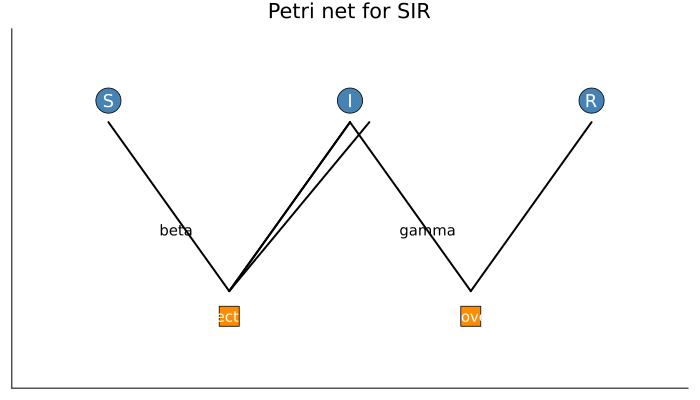

In [3]:
network_plot = plot_sir_network(net)
network_plot

## Детерминированная симуляция

Решается непрерывная версия модели SIR
на равномерной временной сетке.

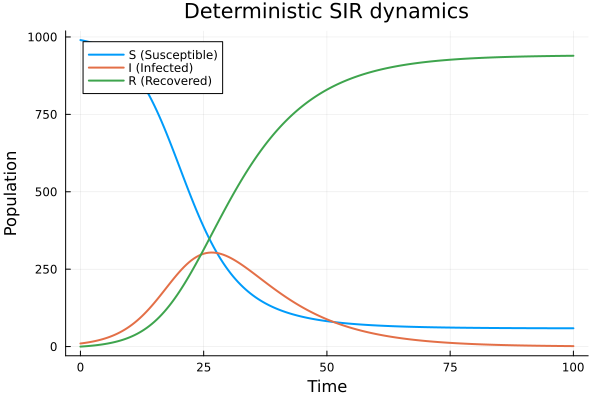

In [4]:
df_det = simulate_deterministic(
    net,
    u0,
    (0.0, tmax);
    saveat = saveat,
    rates = [beta, gamma],
)

det_summary = DataFrame([summarize_trajectory(df_det)])
det_summary


det_plot = plot_sir(df_det; title = "Deterministic SIR dynamics")
det_plot

## Стохастическая симуляция

Запускается прямой метод Гиллеспи.
При большой популяции его траектория близка к сглаженной ОДУ-модели,
но сохраняет случайные флуктуации.

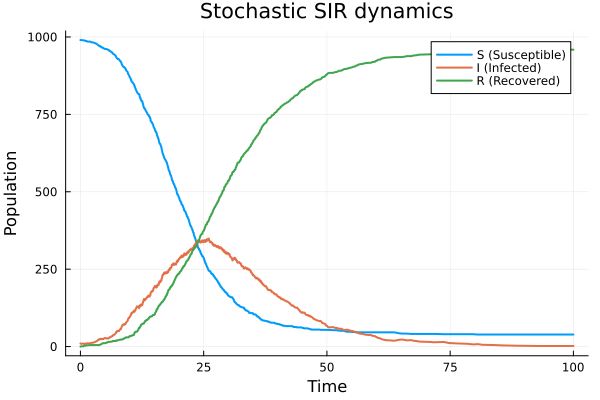

In [5]:
Random.seed!(seed)
df_stoch = simulate_stochastic(
    net,
    u0,
    (0.0, tmax);
    rates = [beta, gamma],
    rng = MersenneTwister(seed),
)

stoch_summary = DataFrame([summarize_trajectory(df_stoch)])
stoch_summary


stoch_plot = plot_sir(df_stoch; title = "Stochastic SIR dynamics")
stoch_plot

## Сравнение по числу инфицированных

В итоговом отчёте полезно сравнивать именно траекторию `I(t)`.

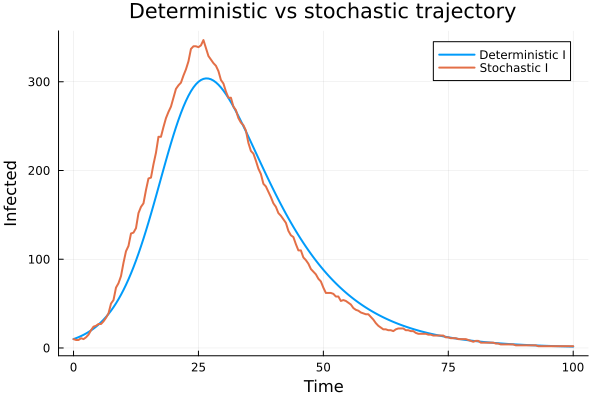

In [6]:
comparison_plot = plot_comparison(df_det, df_stoch)
comparison_plot

## Чувствительность по параметру beta

Исследуется влияние скорости заражения на пик эпидемии
и конечное число выздоровевших.

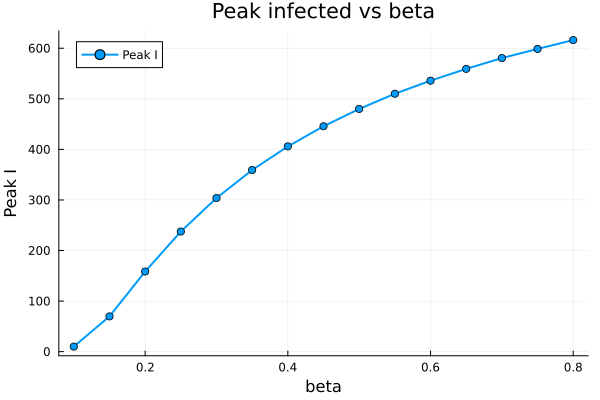

In [7]:
beta_range = 0.10:0.05:0.80
df_scan = parameter_scan(beta_range; gamma = gamma, tmax = tmax, saveat = saveat)
df_scan


scan_plot = plot_scan(df_scan)
scan_plot


sensitivity_plot = plot_sensitivity(df_scan)
sensitivity_plot

## Анимация детерминированной динамики

GIF отражает, как популяция последовательно
перераспределяется между тремя компартментами.

In [8]:
df_anim = simulate_deterministic(
    net,
    u0,
    (0.0, tmax);
    saveat = 1.0,
    rates = [beta, gamma],
)

Row,time,S,I,R
,Float64,Float64,Float64,Float64
1,0.0,990.0,10.0,0.0
2,1.0,986.723,12.1716,1.10511
3,2.0,982.752,14.7988,2.44947
4,3.0,977.948,17.9694,4.08294
5,4.0,972.15,21.7848,6.0648
6,5.0,965.175,26.3598,8.46517
7,6.0,956.811,31.8225,11.3663
8,7.0,946.824,38.3119,14.8638
9,8.0,934.958,45.9741,19.0677


## Краткие выводы

1. Сеть Петри корректно воспроизводит классическую структуру SIR-модели.
2. Стохастическая траектория колеблется вокруг детерминированной,
   но сохраняет те же основные фазы эпидемии.
3. При росте `beta` пик эпидемии и итоговое число переболевших увеличиваются.